
# การรัน Diagnostic Inference

workflow พื้นฐานสำหรับการใช้โมเดลพยากรณ์ร่วมกับโมเดลวินิจฉัย

ตัวอย่างนี้จะแสดงวิธีรัน deterministic inference workflow ที่ใช้ Prognostic Model ควบคู่กับ Diagnostic Model โดยโมเดลวินิจฉัยจะทำนายตัวแปรบรรยากาศเพิ่มเติมจากฟิลด์พยากรณ์ที่ได้จากโมเดลพยากรณ์

ในตัวอย่างนี้คุณจะได้เรียนรู้:

- วิธีสร้างอินสแตนซ์ของ Prognostic Model
- วิธีสร้างอินสแตนซ์ของ Diagnostic Model
- วิธีสร้างแหล่งข้อมูลและออบเจ็กต์ IO
- วิธีรัน diagnostic workflow ที่มีมาให้ในระบบ
- วิธีทำ post-processing กับผลลัพธ์


In [ ]:
# /// script
# dependencies = [
#   "earth2studio[dlwp] @ git+https://github.com/NVIDIA/earth2studio.git",
#   "cartopy",
# ]
# ///

## การเตรียมองค์ประกอบ
ในตัวอย่างนี้ เราจะใช้ workflow วินิจฉัยที่มีมาให้ในระบบคือ :py:meth:`earth2studio.run.diagnostic`.



.. literalinclude:: ../../earth2studio/run.py
   :language: python
   :start-after: # sphinx - diagnostic start
   :end-before: # sphinx - diagnostic end



ดังนั้น เราจึงต้องมีองค์ประกอบต่อไปนี้:

- Prognostic Model: ใช้ FourCastNet รุ่น :py:class:`earth2studio.models.px.FCN` ในตัว
- Diagnostic Model: ใช้ระบบตกตะกอน AFNO รุ่น :py:class:`earth2studio.models.dx.PrecipitationAFNO` ในตัว
- Datasource: ดึงข้อมูลจาก GFS data API ผ่าน :py:class:`earth2studio.data.GFS`.
- IO Backend: บันทึกเอาต์พุตลงในร้านค้า Zarr :py:class:`earth2studio.io.ZarrBackend`



In [1]:
import os

os.makedirs("outputs", exist_ok=True)
from dotenv import load_dotenv

load_dotenv()  # สิ่งที่ต้องทำ: สร้างฟังก์ชันการเตรียมตัวอย่างทั่วไป

from earth2studio.data import GFS
from earth2studio.io import ZarrBackend
from earth2studio.models.dx import PrecipitationAFNO
from earth2studio.models.px import FCN

# โหลดmodel packageเริ่มต้นซึ่งดาวน์โหลดcheckpointจาก NGC
package = FCN.load_default_package()
prognostic_model = FCN.load_model(package)

package = PrecipitationAFNO.load_default_package()
diagnostic_model = PrecipitationAFNO.load_model(package)

# สร้างแหล่งข้อมูล
data = GFS()

# สร้างตัวจัดการ IO เก็บไว้ในหน่วยความจำ
io = ZarrBackend()

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.


## การรัน Workflow
เมื่อคอมโพเนนต์ทั้งหมดเริ่มต้นแล้ว การรัน workflow จะเป็นโค้ด Python บรรทัดเดียว
เวิร์กโฟลว์จะส่งคืนอ็อบเจ็กต์ IO ที่ระบุกลับไปยังผู้ใช้ ซึ่งสามารถนำมาใช้ได้
จากนั้นจึงโพสต์กระบวนการ บางตัวมี API เพิ่มเติมซึ่งมีประโยชน์สำหรับ post-processing หรือ
บันทึกเป็นไฟล์ ตรวจสอบเอกสาร API สำหรับข้อมูลเพิ่มเติม



In [2]:
import earth2studio.run as run

nsteps = 8
io = run.diagnostic(
    ["2026-04-23"], nsteps, prognostic_model, diagnostic_model, data, io
)

print(io.root.tree())

2026-04-24 11:24:18.041 | INFO     | earth2studio.run:diagnostic:198 - Running diagnostic workflow!
2026-04-24 11:24:18.041 | INFO     | earth2studio.run:diagnostic:205 - Inference device: cuda


Fetching GFS data:   4%|▍         | 1/26 [00:00<00:03,  7.07it/s]

2026-04-24 11:24:18.354 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 343446027-948558
2026-04-24 11:24:18.396 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 463644159-977853
2026-04-24 11:24:18.397 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 335796215-908044
2026-04-24 11:24:18.399 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 464622012-968236
2026-04-24 11:24:18.400 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20260423/00/atmos/gfs.t00z.pgrb2.0p25.f000 418030152-967622
2026-04-24 11:24:18.401 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS 

Fetching GFS data: 100%|██████████| 26/26 [00:03<00:00,  6.86it/s]


2026-04-24 11:24:22.169 | SUCCESS  | earth2studio.run:diagnostic:228 - Fetched data from GFS
2026-04-24 11:24:22.179 | INFO     | earth2studio.run:diagnostic:260 - Inference starting!


Running inference: 100%|██████████| 9/9 [00:06<00:00,  1.40it/s]

2026-04-24 11:24:28.611 | SUCCESS  | earth2studio.run:diagnostic:276 - 
Inference complete
/
├── lat (720,) float64
├── lead_time (9,) timedelta64[h]
├── lon (1440,) float64
├── time (1,) datetime64[ns]
└── tp (1, 9, 720, 1440) float32



## การทำ Post-Processing
ขั้นตอนสุดท้ายคือการพล็อตปริมาณฝนรวมที่คาดการณ์ได้ พลังของ
โมเดลการวินิจฉัยคืออนุญาตให้คาดการณ์ตัวแปรใดๆ จากการฝึกอบรมล่วงหน้าได้
Prognostic Model.

<div class="alert alert-info"><h4>หมายเหตุ</h4><p>workflow ในตัวจะบันทึกเฉพาะเอาต์พุตโดยตรงของการวินิจฉัยเท่านั้น ในเรื่องนี้
ตัวอย่าง มีเพียงปริมาณฝนทั้งหมดเท่านั้นที่สามารถเข้าถึงได้สำหรับการพล็อต หากคุณต้องการที่จะบันทึก
ผลลัพธ์ของการพยากรณ์และการวินิจฉัย เราขอแนะนำให้เขียนworkflow แบบกำหนดเอง.</p></div>



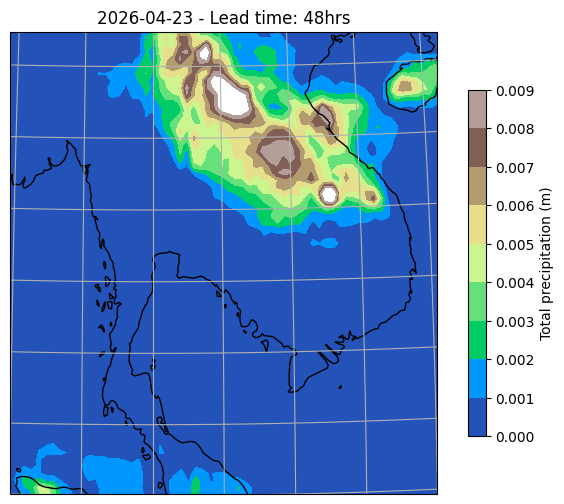

In [6]:
from datetime import datetime

import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import numpy as np

forecast = datetime(2026, 4, 23)
variable = "tp"
step = 8  # lead time = 48 ชม

plt.close("all")
# สร้าง Orthographic projection ของ USA
# projection = ccrs.Orthographic(-100, 40)

# สร้าง Orthographic projection ของ TH
projection = ccrs.Orthographic(100, 15)

# สร้างรูปและแกนด้วย projection ที่ระบุ
fig, ax = plt.subplots(subplot_kw={"projection": projection}, figsize=(10, 6))

## พล็อตฟิลด์โดยใช้ pcolormesh
# พล็อตฟิลด์ด้วย contourf
levels = np.arange(0.0, 0.01, 0.001)
im = ax.contourf(
    io["lon"][:],
    io["lat"][:],
    io[variable][0, step],
    levels,
    transform=ccrs.PlateCarree(),
    vmax=0.01,
    vmin=0.00,
    cmap="terrain",
)

# ตั้งชื่อเรื่อง
ax.set_title(f"{forecast.strftime('%Y-%m-%d')} - Lead time: {6*step}hrs")

# เพิ่มแนวชายฝั่งและเส้นกริด
# set_extent รับค่าเป็น [west, east, south, north] ในพิกัด PlateCarree
ax.set_extent([95, 110, 5, 21], crs=ccrs.PlateCarree())

# เพิ่มแนวชายฝั่งและเส้นตาราง6
#ax.set_extent([220, 340, 20, 70])  # [lat min, lat max, lon min, lon max]
ax.coastlines()
ax.gridlines()
plt.colorbar(
    im, ax=ax, ticks=levels, shrink=0.75, pad=0.04, label="Total precipitation (m)"
)

plt.savefig("outputs/02_tp_prediction.jpg")